In [1]:
import sys
sys.path.append('src')

import time
import random
import numpy as np
import matplotlib.pyplot as plt

from city_data import CityData
from bst import BST
from avl_tree import AVLTree
from min_heap import MinHeap
from hash_table import HashTable

print("Imports successful")

Imports successful


In [2]:
def generate_cities(n, seed=42):
    """Generate n cities with unique names and random data."""
    rng = random.Random(seed)
    cities = []
    for i in range(n):
        name = f"City{i:06d}"  # unique, zero-padded so BST/AVL don't get sorted-order bias
        lat = rng.uniform(26.0, 30.0)
        lon = rng.uniform(80.0, 88.0)
        pop = rng.randint(1000, 2000000)
        dist = rng.uniform(0, 1000)
        cities.append(CityData(name, lat, lon, pop, dist))
    return cities

# Shuffle a copy of names for random-order search/delete testing
def shuffled_names(cities, seed=99):
    names = [c.name for c in cities]
    random.Random(seed).shuffle(names)
    return names

sizes = [100, 1000, 10000]
datasets = {n: generate_cities(n) for n in sizes}

for n in sizes:
    print(f"n={n}: first city = {datasets[n][0]}, last city = {datasets[n][-1]}")

n=100: first city = City(City000000, pop=577778, dist=244.8918538034762), last city = City(City000099, pop=1970723, dist=27.600535119635893)
n=1000: first city = City(City000000, pop=577778, dist=244.8918538034762), last city = City(City000999, pop=1299275, dist=637.5381224199976)
n=10000: first city = City(City000000, pop=577778, dist=244.8918538034762), last city = City(City009999, pop=867560, dist=526.6094289420748)


In [3]:
def time_bst(cities, search_names, delete_names):
    tree = BST()
    t0 = time.perf_counter()
    for c in cities:
        tree.insert(c)
    insert_time = time.perf_counter() - t0

    t0 = time.perf_counter()
    for name in search_names:
        tree.search(name)
    search_time = time.perf_counter() - t0

    t0 = time.perf_counter()
    for name in delete_names:
        tree.delete(name)
    delete_time = time.perf_counter() - t0

    return insert_time, search_time, delete_time


def time_avl(cities, search_names, delete_names):
    tree = AVLTree()
    t0 = time.perf_counter()
    for c in cities:
        tree.insert(c)
    insert_time = time.perf_counter() - t0

    t0 = time.perf_counter()
    for name in search_names:
        tree.search(name)
    search_time = time.perf_counter() - t0

    t0 = time.perf_counter()
    for name in delete_names:
        tree.delete(name)
    delete_time = time.perf_counter() - t0

    return insert_time, search_time, delete_time


def time_heap(cities):
    """Heap doesn't support arbitrary search/delete-by-key (only extract-min),
    so we time insert and extract_min (its version of 'delete')."""
    heap = MinHeap()
    t0 = time.perf_counter()
    for c in cities:
        heap.insert(c)
    insert_time = time.perf_counter() - t0

    t0 = time.perf_counter()
    peek = heap.peek_min()
    search_time = time.perf_counter() - t0  # peek is the heap's equivalent of "fast access"

    t0 = time.perf_counter()
    while not heap.is_empty():
        heap.extract_min()
    delete_time = time.perf_counter() - t0

    return insert_time, search_time, delete_time


def time_hash(cities, search_names, delete_names):
    ht = HashTable()
    t0 = time.perf_counter()
    for c in cities:
        ht.insert(c)
    insert_time = time.perf_counter() - t0

    t0 = time.perf_counter()
    for name in search_names:
        ht.search(name)
    search_time = time.perf_counter() - t0

    t0 = time.perf_counter()
    for name in delete_names:
        ht.delete(name)
    delete_time = time.perf_counter() - t0

    return insert_time, search_time, delete_time


print("Timing functions defined")

Timing functions defined


In [5]:
def shuffled_copy(cities, seed=7):
    """Random insertion order — avoids BST worst-case (sorted-input) degeneration."""
    shuffled = cities.copy()
    random.Random(seed).shuffle(shuffled)
    return shuffled

In [6]:
results = []

for n in sizes:
    cities = datasets[n]
    insertion_order = shuffled_copy(cities, seed=7)
    search_names = shuffled_names(cities, seed=1)
    delete_names = shuffled_names(cities, seed=2)

    # BST
    ins, srch, dele = time_bst(insertion_order, search_names, delete_names)
    results.append({"structure": "BST", "n": n, "insert": ins, "search": srch, "delete": dele})

    # AVL
    ins, srch, dele = time_avl(insertion_order, search_names, delete_names)
    results.append({"structure": "AVL", "n": n, "insert": ins, "search": srch, "delete": dele})

    # Min-Heap
    ins, srch, dele = time_heap(insertion_order)
    results.append({"structure": "MinHeap", "n": n, "insert": ins, "search": srch, "delete": dele})

    # Hash Table
    ins, srch, dele = time_hash(insertion_order, search_names, delete_names)
    results.append({"structure": "HashTable", "n": n, "insert": ins, "search": srch, "delete": dele})

    print(f"Completed timing for n={n}")

print("\nAll timing tests complete")

Completed timing for n=100
Completed timing for n=1000
Completed timing for n=10000

All timing tests complete


In [7]:
import pandas as pd

df = pd.DataFrame(results)
df = df[["structure", "n", "insert", "search", "delete"]]

# Display with more readable formatting (milliseconds instead of raw seconds)
df_display = df.copy()
for col in ["insert", "search", "delete"]:
    df_display[col] = (df_display[col] * 1000).round(3)  # convert to ms
df_display = df_display.rename(columns={"insert": "insert_ms", "search": "search_ms", "delete": "delete_ms"})

df_display

,structure,n,insert_ms,search_ms,delete_ms
0,BST,100,0.230,0.192,0.259
1,AVL,100,0.719,0.108,0.767
2,MinHeap,100,0.127,0.001,0.330
3,HashTable,100,0.335,0.046,0.071
4,BST,1000,1.821,1.905,2.265
5,AVL,1000,5.376,0.954,4.126
6,MinHeap,1000,0.618,0.001,2.056
7,HashTable,1000,1.517,0.163,0.251
8,BST,10000,13.860,11.440,10.932
9,AVL,10000,27.042,6.069,22.231


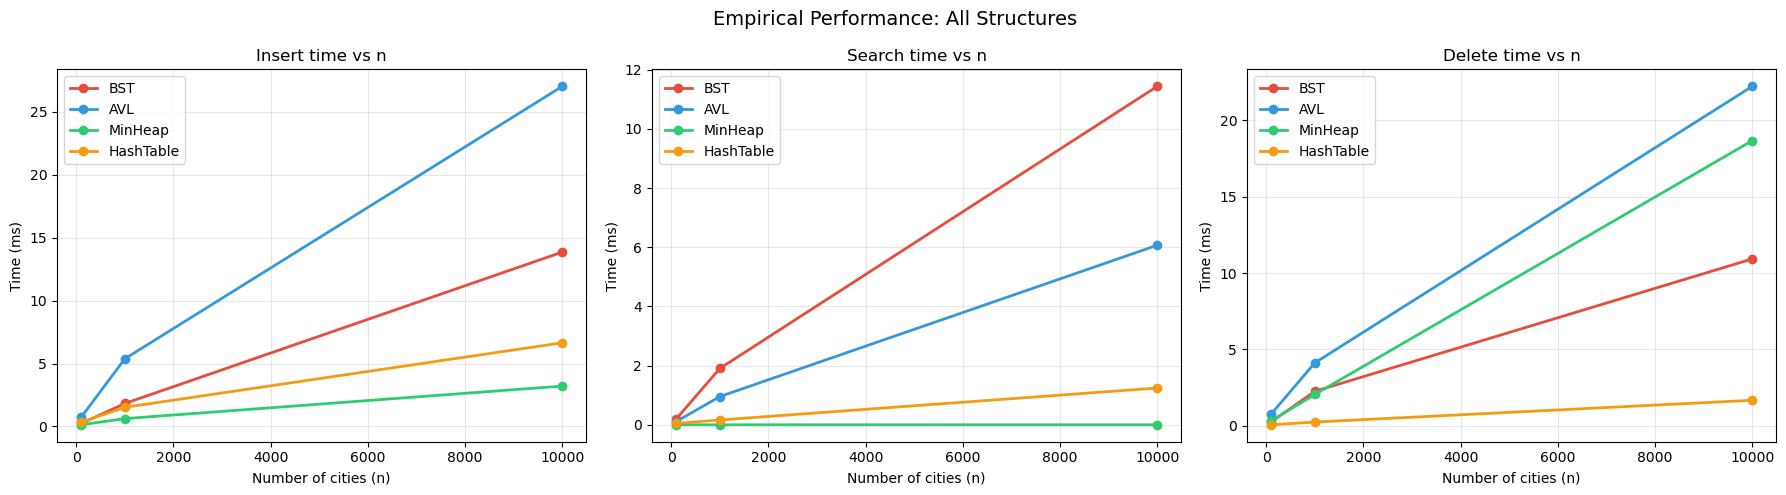

In [8]:
operations = ["insert", "search", "delete"]
structures = ["BST", "AVL", "MinHeap", "HashTable"]
colors = {"BST": "#e74c3c", "AVL": "#3498db", "MinHeap": "#2ecc71", "HashTable": "#f39c12"}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, op in zip(axes, operations):
    for struct in structures:
        sub = df[df["structure"] == struct].sort_values("n")
        ax.plot(sub["n"], sub[op] * 1000, marker='o', label=struct, color=colors[struct], linewidth=2)
    ax.set_xlabel("Number of cities (n)")
    ax.set_ylabel("Time (ms)")
    ax.set_title(f"{op.capitalize()} time vs n")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle("Empirical Performance: All Structures", fontsize=14)
plt.tight_layout()
plt.show()

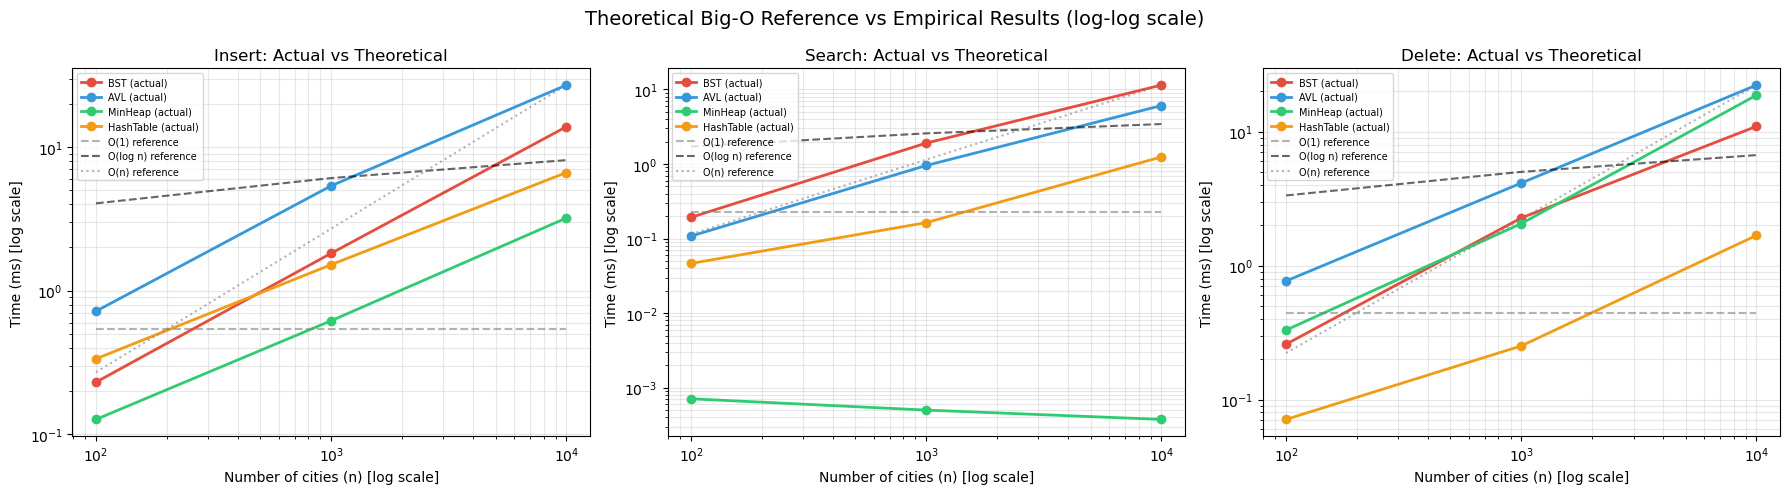

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
n_values = np.array(sorted(df["n"].unique()))

for ax, op in zip(axes, operations):
    for struct in structures:
        sub = df[df["structure"] == struct].sort_values("n")
        ax.plot(sub["n"], sub[op] * 1000, marker='o', label=f"{struct} (actual)",
                 color=colors[struct], linewidth=2)

    # Reference theoretical curves, scaled to roughly match the actual data's range
    ref_scale = df[df["n"] == 10000][op].max() * 1000
    o1 = np.ones_like(n_values, dtype=float) * (ref_scale * 0.02)
    ologn = np.log2(n_values) * (ref_scale / np.log2(n_values[-1]) * 0.3)
    on = n_values * (ref_scale / n_values[-1])

    ax.plot(n_values, o1, '--', color='gray', alpha=0.6, label='O(1) reference')
    ax.plot(n_values, ologn, '--', color='black', alpha=0.6, label='O(log n) reference')
    ax.plot(n_values, on, ':', color='gray', alpha=0.6, label='O(n) reference')

    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel("Number of cities (n) [log scale]")
    ax.set_ylabel("Time (ms) [log scale]")
    ax.set_title(f"{op.capitalize()}: Actual vs Theoretical")
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3, which='both')

plt.suptitle("Theoretical Big-O Reference vs Empirical Results (log-log scale)", fontsize=14)
plt.tight_layout()
plt.show()

## Theoretical Time Complexity Summary

| Notes |
|---|
| BST worst case occurs with sorted/skewed insertion order (degenerates to a linked list) — demonstrated earlier in `02_avl_tree.ipynb`. |
| AVL guarantees O(log n) even in the worst case, at the cost of rotation overhead on every insert/delete. |
| Min-Heap only guarantees fast access to the *minimum* element (O(1) peek); searching for an arbitrary city by name is O(n) since heap order doesn't help with arbitrary key lookup. |
| Hash Table worst case (O(n)) occurs only if many keys collide into the same bucket — rare in practice with a good hash function and our load-factor-based resizing. |

In [10]:
theoretical = pd.DataFrame([
    {"Structure": "BST",       "Insert (avg)": "O(log n)", "Insert (worst)": "O(n)",
     "Search (avg)": "O(log n)", "Search (worst)": "O(n)",
     "Delete (avg)": "O(log n)", "Delete (worst)": "O(n)"},
    {"Structure": "AVL Tree",  "Insert (avg)": "O(log n)", "Insert (worst)": "O(log n)",
     "Search (avg)": "O(log n)", "Search (worst)": "O(log n)",
     "Delete (avg)": "O(log n)", "Delete (worst)": "O(log n)"},
    {"Structure": "Min-Heap",  "Insert (avg)": "O(log n)", "Insert (worst)": "O(log n)",
     "Search (avg)": "O(1) [min only]", "Search (worst)": "O(n) [arbitrary key]",
     "Delete (avg)": "O(log n) [extract-min]", "Delete (worst)": "O(log n)"},
    {"Structure": "Hash Table","Insert (avg)": "O(1)", "Insert (worst)": "O(n)",
     "Search (avg)": "O(1)", "Search (worst)": "O(n)",
     "Delete (avg)": "O(1)", "Delete (worst)": "O(n)"},
])

theoretical

,Structure,Insert (avg),Insert (worst),Search (avg),Search (worst),Delete (avg),Delete (worst)
0,BST,O(log n),O(n),O(log n),O(n),O(log n),O(n)
1,AVL Tree,O(log n),O(log n),O(log n),O(log n),O(log n),O(log n)
2,Min-Heap,O(log n),O(log n),O(1) [min only],O(n) [arbitrary key],O(log n) [extract-min],O(log n)
3,Hash Table,O(1),O(n),O(1),O(n),O(1),O(n)


## The Constant Factor: Why Big-O Alone Isn't Enough

Big-O notation describes *growth rate*, not actual speed — it hides a constant
factor (and lower-order terms) that can matter a lot in practice. Our empirical
results demonstrate this clearly:

**AVL vs BST — same complexity class, different real speed.**
Both are O(log n) for insert on average, yet at n=10,000 our measurements show
AVL insert taking roughly **2x longer** than plain BST insert (~27ms vs ~14ms).
The reason: AVL performs extra bookkeeping on every insertion — checking the
balance factor and potentially executing rotations — that a plain BST simply
doesn't do. Big-O notation treats both as "O(log n)" and hides this real,
measurable overhead. In a system with very frequent inserts and where worst-case
guarantees matter less than raw average speed, this constant factor could be a
genuine reason to prefer a plain BST over an AVL tree.

**Why our insert/delete curves looked closer to O(n) than O(log n) on the log-log
graph.** Our test loops perform n operations back-to-back (`for c in cities:
tree.insert(c)`), so total measured time = n operations × O(log n) per operation
= O(n log n) overall — not O(log n). Since log(n) grows so slowly, n log n looks
visually very close to a straight O(n) line over the range we tested (100 to
10,000). This is an artifact of *how we measured* (total time for n operations),
not evidence that any individual insert/search/delete violates its theoretical
per-operation complexity.

**Practical significance.** In a real route-planning application, this means
choosing a data structure isn't just about matching the "best" Big-O class —
it's also about which structure has lower fixed overhead for the specific
workload size and pattern you expect. For a small number of cities (e.g. under
1,000), the constant-factor differences we measured are all under a few
milliseconds and are unlikely to matter. At larger scales, or in
latency-sensitive systems, the constant factor becomes the deciding factor
between structures in the same asymptotic class.

## Which Data Structure Fits Which Use Case?

**Frequent inserts, order doesn't matter (e.g. bulk-loading new cities into the
system):** **Hash Table.** Our results show it has by far the fastest insert
time at every tested size (6.6ms at n=10,000, vs 14ms BST / 27ms AVL), thanks
to O(1) average insertion with no rebalancing or tree-traversal cost.

**Frequent lookups by city name (e.g. "does this city exist / what's its
population?"):** **Hash Table.** Search time stayed the lowest and grew the
slowest across all tested sizes (1.2ms at n=10,000 vs 6-11ms for BST/AVL),
consistent with its O(1) average-case search.

**Priority access — "what's the next nearest city to visit?" (core route-planning
operation):** **Min-Heap.** This is the only structure of the four purpose-built
for this exact operation — `peek_min()` gives O(1) access to the closest
unvisited city, and `extract_min()` maintains the heap in O(log n). Neither BST,
AVL, nor Hash Table can efficiently answer "what's the minimum-distance city"
without a full O(n) scan.

**Data that needs to stay sorted by name/key AND supports guaranteed worst-case
performance (e.g. a safety-critical system that cannot tolerate an occasional
slow O(n) lookup):** **AVL Tree.** Although it was consistently the slowest of
the four for raw insert speed in our tests, it's the only structure that
*guarantees* O(log n) even in the worst case (e.g. adversarial or sorted input).
Plain BST offers no such guarantee — a sorted or adversarial insertion order
degrades it to O(n), as demonstrated directly in our AVL notebook (a 15-node
sorted insertion gave BST a theoretical height of 14, while AVL stayed at
height 3).

**Plain BST is generally the weakest choice for this application** — it offers
no advantage over AVL in the worst case, is slower than Hash Table for lookups,
and lacks the Min-Heap's priority-queue capability. It's most justifiable as a
simple baseline for comparison (which is exactly the role it plays in this
report), or in a context where insertion order is guaranteed to be random and
sorted structure (in-order traversal / range queries) is needed — a capability
Hash Table lacks entirely.